# Briefer than brief: Explainer

In [2]:
import btb
import numpy as np

In [3]:
# parameters
vir_tau = 0.005
speedup = 2
frame_rate = 480

times = btb.generate_times(stim_dur = 0.3)
vir = btb.adelson_bergen_vir(times, tau=vir_tau) / frame_rate * 3
vir = np.roll(vir, int(len(vir)/2))
stim = btb.generate_stim(times, isi=0, pulse_duration=1)
stim_btb, scaling_factor = btb.generate_btb(stim, times,
                                            vir_tau=vir_tau, speedup=speedup)

Text(0.5, 1.0, 'target response (original VIR)')

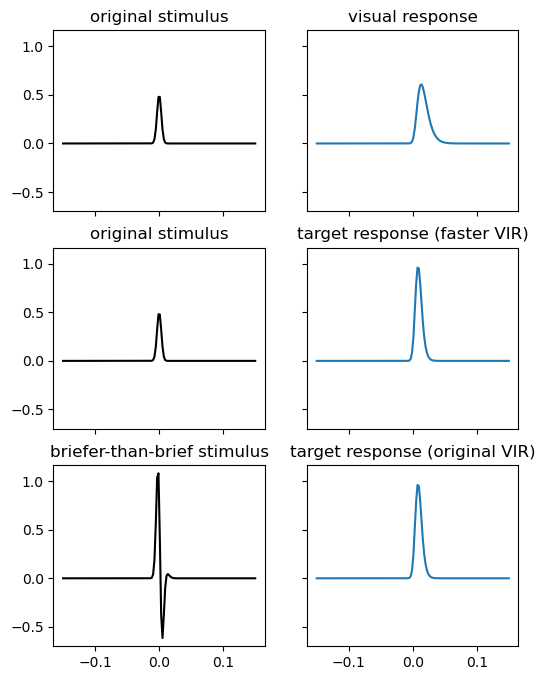

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 2, sharex=True, sharey=True, figsize=(6, 8))
ax = ax.ravel()

# original stimulus
ax[0].plot(times-0.15, stim, color='black')
ax[0].set_title('original stimulus')
visual_response = np.convolve(stim, vir, mode='same')
ax[1].plot(times-0.15, visual_response)
ax[1].set_title('visual response')

ax[2].plot(times-0.15, stim, color='black')
ax[2].set_title('original stimulus')
vir2 = btb.adelson_bergen_vir(times, tau=vir_tau/speedup) / frame_rate * 3
vir2 = np.roll(vir2, int(len(vir2)/2))
visual_response2 = np.convolve(stim, vir2, mode='same')
ax[3].plot(times-0.15, visual_response2)
ax[3].set_title('target response (faster VIR)')

ax[4].plot(times-0.15, stim_btb, color='black')
ax[4].set_title('briefer-than-brief stimulus')
visual_response3 = np.convolve(stim_btb, vir, mode='same')
ax[5].plot(times-0.15, visual_response2)
ax[5].set_title('target response (original VIR)')


In [5]:
fig.subplots_adjust(hspace=-0.2, wspace=0.35)
for i in range(6):
    ax[i].axis('off')
    ax[i].set_title('')

fig.savefig('all_traces.svg')

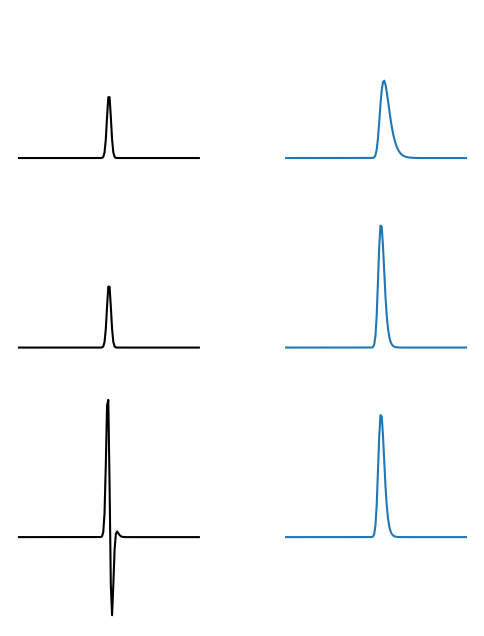

In [6]:
fig

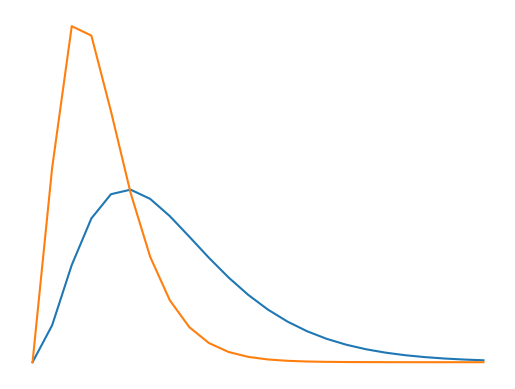

In [7]:
plt.plot(np.roll(vir, len(vir)//2)[:-120])
plt.plot(np.roll(vir2, len(vir2)//2)[:-120])
plt.axis('off')

plt.savefig('VIR.svg')

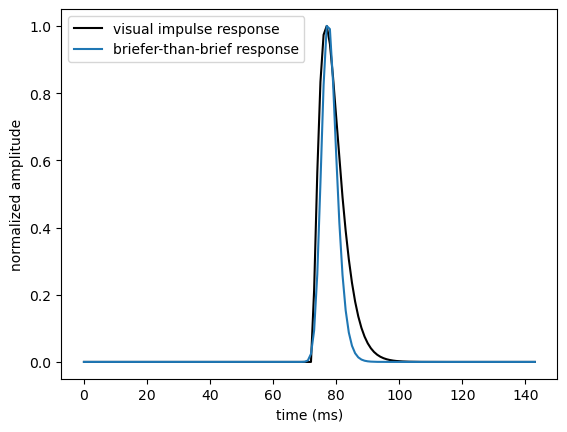

In [8]:
plt.plot(vir/np.max(vir), color='black',
        label='visual impulse response')
plt.plot(np.roll(visual_response2/np.max(visual_response2), 2),
        label='briefer-than-brief response')

plt.xlabel('time (ms)')
plt.ylabel('normalized amplitude')

plt.legend()
plt.savefig('btb_vs_vir.png', dpi=600)

In [9]:
# demonstration code for manuscript
import numpy as np
from scipy.fft import fft, ifft
from math import factorial

# step 1: fix visual impulse response (VIR)
n   = 2
tau = 0.005
t   = np.linspace(0, 0.5, 500)

vir = 1/tau * np.exp(-t / tau) * (t / tau)**n / factorial(n)
vir = np.roll(vir, int(len(t)/2)) # center to prevent edge artifacts

# step 2: what if VIR were briefer?
s         = 2
tau_prime = tau / s
vir_prime = 1/tau_prime * np.exp(-t / tau_prime) * (t / tau_prime)**n / factorial(n)
vir_prime = np.roll(vir_prime, int(len(t)/2))

# estimated sped up response through convolution, 
stimulus    = np.exp(-(t - 0.25)**2 / (2 * 0.005**2))
stim_prime  = np.convolve(stimulus, vir_prime, mode='same') 

# step 3: calculate stimulus that produces target response
stim_btb = ifft(fft(stim_prime) / fft(vir)).real
stim_btb = np.roll(stim_btb, int(len(t)/2)-1)